# Binocular Overlap Sweep — Visual Field Comparison

Compares 7 visual configurations with varying binocular overlap.

**Overlap formula (analytical, distance-dependent):**

Given cameras separated by distance `s` (7.2mm after 0.9x rescale), with half-FOV `alpha = fovy/2 = 40 deg` and yaw offset `theta`:

    overlap_width(d) = 2d * tan(alpha - theta) - s
    overlap_angle(d) = 2 * arctan(overlap_width(d) / (2d))

The naive formula `fovy - 2 * offset` gives the **far-field** (d -> infinity) overlap.
At finite distances, inter-eye separation reduces the effective overlap.

**Important:** Vertical FOV overlap is always 100% regardless of horizontal offset.
Both eyes always see the same vertical angular range. This is why rendered images
appear similar even at "0 deg horizontal overlap."

| Condition | `eye_angle_offset` | Far-field Overlap | Overlap @10cm | Overlap @30cm |
|-----------|-------------------|------------------|--------------|--------------|
| Full overlap | 0.0 rad | 80 deg | ~79 deg | ~80 deg |
| Default | 0.2 rad | 57 deg | ~54 deg | ~56 deg |
| Rat-like (high) | 0.262 rad | 50 deg | ~47 deg | ~49 deg |
| Rat-like (low) | 0.349 rad | 40 deg | ~36 deg | ~39 deg |
| Narrow | 0.524 rad | 20 deg | ~14 deg | ~18 deg |
| No overlap | 0.698 rad | 0 deg | 0 deg | 0 deg |

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

In [2]:
import jax
import jax.numpy as jp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge, FancyArrowPatch
import numpy as np
from tqdm import tqdm

from vnl_playground.tasks.rodent.run_gap_vision import RunGapVision, default_config
from vnl_playground.tasks.rodent.vision_jax import JaxVisionRenderer
from mujoco.mjx.warp.types import DATA_NON_VMAP

In [3]:
def compute_analytical_overlap(
    eye_angle_offset, fovy_deg=80.0, inter_eye_dist=0.008, rescale_factor=0.9
):
    """Compute distance-dependent binocular overlap analytically.

    Uses camera xpos separation and configured eye angle offset to compute
    the horizontal angular overlap as a function of distance from the skull.

    For two cameras separated by distance s, with half-FOV alpha and yaw offset theta:
        overlap_width(d) = 2d * tan(alpha - theta) - s
        overlap_angle(d) = 2 * arctan(overlap_width(d) / (2d))

    At d -> infinity, this converges to fovy - 2*theta (the naive formula).
    At finite d, inter-eye separation s reduces the effective overlap.

    Args:
        eye_angle_offset: Yaw offset per eye in radians.
        fovy_deg: Vertical field of view in degrees (= horizontal for square images).
        inter_eye_dist: Raw inter-eye distance in meters (from XML: 2 * 0.004).
        rescale_factor: Model rescale factor (default 0.9).

    Returns:
        distances: array of distances (m)
        overlap_angles: array of horizontal overlap angles (degrees) at each distance
        far_field_overlap: asymptotic overlap (degrees) at infinite distance
        d_min: minimum distance for any overlap to exist (m), or inf if no overlap
    """
    s = inter_eye_dist * rescale_factor
    alpha = np.radians(fovy_deg / 2)
    theta = eye_angle_offset

    far_field_overlap = max(0, fovy_deg - 2 * np.degrees(theta))

    if theta >= alpha:
        distances = np.linspace(0.01, 2.0, 200)
        return distances, np.zeros_like(distances), 0.0, np.inf

    tan_diff = np.tan(alpha - theta)
    d_min = s / (2 * tan_diff) if tan_diff > 0 else np.inf

    distances = np.linspace(0.01, 2.0, 200)
    overlap_widths = 2 * distances * tan_diff - s
    overlap_widths = np.maximum(overlap_widths, 0)
    overlap_angles = np.degrees(2 * np.arctan(overlap_widths / (2 * distances)))

    return distances, overlap_angles, far_field_overlap, d_min


def get_inter_eye_distance_from_model(env):
    """Extract inter-eye distance from MuJoCo model camera positions."""
    import mujoco

    m = env.mj_model
    suffix = getattr(env, "_suffix", "-rodent")
    left_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_CAMERA, f"eye_left{suffix}")
    right_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_CAMERA, f"eye_right{suffix}")
    if left_id >= 0 and right_id >= 0:
        left_pos = m.cam_pos[left_id]
        right_pos = m.cam_pos[right_id]
        return float(np.linalg.norm(left_pos - right_pos))
    return 0.008

## 1. Define Experimental Conditions

In [4]:
# Each condition: (label, binocular?, eye_angle_offset, overlap_deg)
CONDITIONS = [
    ("Monocular\nfrontal", False, None, None),
    ("Full overlap\n80°", True, 0.0, 80),
    ("Default\n57°", True, 0.2, 57),
    ("Rat-like (high)\n50°", True, 0.262, 50),
    ("Rat-like (low)\n40°", True, 0.349, 40),
    ("Narrow\n20°", True, 0.524, 20),
    ("No overlap\n0°", True, 0.698, 0),
]

WIDTH, HEIGHT = 64, 64  # render resolution (larger than 32 for visualization)
NWORLD = 1

print(f"Rendering {len(CONDITIONS)} conditions at {WIDTH}x{HEIGHT} RGB")

Rendering 7 conditions at 64x64 RGB


In [5]:
INTER_EYE_DIST = 0.008
RESCALE_FACTOR = 0.9
FOVY = 80.0

print(f"Inter-eye distance (raw): {INTER_EYE_DIST*1000:.1f}mm")
print(f"Inter-eye distance (scaled): {INTER_EYE_DIST*RESCALE_FACTOR*1000:.1f}mm")
print(f"Camera fovy: {FOVY} deg")
print()

analytical_overlaps = {}
for label, binocular, offset, nominal_overlap in CONDITIONS:
    if not binocular or offset is None:
        continue
    distances, overlap_angles, far_field, d_min = compute_analytical_overlap(
        offset,
        fovy_deg=FOVY,
        inter_eye_dist=INTER_EYE_DIST,
        rescale_factor=RESCALE_FACTOR,
    )
    d_01 = overlap_angles[np.argmin(np.abs(distances - 0.1))]
    d_03 = overlap_angles[np.argmin(np.abs(distances - 0.3))]
    analytical_overlaps[label] = {
        "distances": distances,
        "overlap_angles": overlap_angles,
        "far_field": far_field,
        "d_min": d_min,
        "at_0.1m": d_01,
        "at_0.3m": d_03,
    }
    print(
        f"{label.replace(chr(10), ' ')}: far-field={far_field:.1f} deg, "
        f"at 0.1m={d_01:.1f} deg, at 0.3m={d_03:.1f} deg, d_min={d_min*1000:.1f}mm"
    )

Inter-eye distance (raw): 8.0mm
Inter-eye distance (scaled): 7.2mm
Camera fovy: 80.0 deg

Full overlap 80°: far-field=80.0 deg, at 0.1m=77.5 deg, at 0.3m=79.2 deg, d_min=4.3mm
Default 57°: far-field=57.1 deg, at 0.1m=53.9 deg, at 0.3m=56.0 deg, d_min=6.6mm
Rat-like (high) 50°: far-field=50.0 deg, at 0.1m=46.5 deg, at 0.3m=48.8 deg, d_min=7.7mm
Rat-like (low) 40°: far-field=40.0 deg, at 0.1m=36.3 deg, at 0.3m=38.8 deg, d_min=9.9mm
Narrow 20°: far-field=20.0 deg, at 0.1m=15.9 deg, at 0.3m=18.6 deg, d_min=20.5mm
No overlap 0°: far-field=0.0 deg, at 0.1m=0.0 deg, at 0.3m=0.0 deg, d_min=27334.7mm


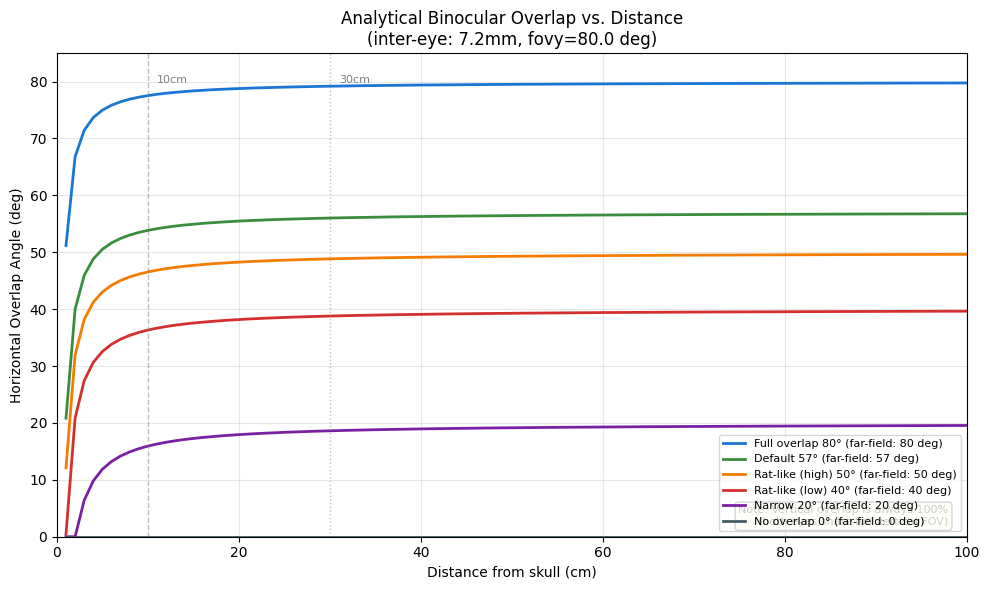

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

binocular_colors = ["#1976D2", "#388E3C", "#F57C00", "#D32F2F", "#7B1FA2", "#455A64"]

for i, (label, binocular, offset, nominal_overlap) in enumerate(CONDITIONS):
    if not binocular or offset is None:
        continue
    data = analytical_overlaps[label]
    ax.plot(
        data["distances"] * 100,
        data["overlap_angles"],
        label=f"{label.replace(chr(10), ' ')} (far-field: {data['far_field']:.0f} deg)",
        color=binocular_colors[i - 1],
        lw=2,
    )

for d_cm, ls in [(10, "--"), (30, ":")]:
    ax.axvline(d_cm, color="gray", linestyle=ls, alpha=0.5, lw=1)
    ax.text(d_cm + 1, ax.get_ylim()[1] * 0.95, f"{d_cm}cm", fontsize=8, color="gray")

ax.set_xlabel("Distance from skull (cm)")
ax.set_ylabel("Horizontal Overlap Angle (deg)")
ax.set_title(
    "Analytical Binocular Overlap vs. Distance\n"
    f"(inter-eye: {INTER_EYE_DIST*RESCALE_FACTOR*1000:.1f}mm, fovy={FOVY} deg)"
)
ax.legend(fontsize=8)
ax.set_xlim(0, 100)
ax.set_ylim(0, 85)
ax.grid(alpha=0.3)

ax.text(
    0.98,
    0.02,
    "Note: Vertical overlap is always 100%\n(both eyes share full vertical FOV)",
    transform=ax.transAxes,
    fontsize=8,
    ha="right",
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8),
)

plt.tight_layout()
plt.show()

## 2. Create Environments and Renderers

In [7]:
def add_batch_dim(data):
    """Add a leading nworld=1 dimension to mjx.Data, skipping non-vmap fields."""

    def _maybe_expand(path, x):
        parts = [p.name for p in path if hasattr(p, "name") and p.name != "_impl"]
        attr = "__".join(parts)
        if attr in DATA_NON_VMAP:
            return x
        return x[None, ...]

    return jax.tree.map_with_path(_maybe_expand, data)


envs = {}  # label -> env
renderers = {}  # label -> dict of renderers

for label, binocular, offset, overlap_deg in tqdm(CONDITIONS, desc="Building envs"):
    cfg = default_config()
    cfg.mujoco_impl = "warp"
    cfg.use_mesh_platforms = True
    cfg.aesthetic = "outdoor_natural"
    cfg.binocular = binocular
    if offset is not None:
        cfg.eye_angle_offset = offset

    env = RunGapVision(config=cfg)
    envs[label] = env

    if binocular:
        # Create separate renderers for left and right eyes
        left_r = JaxVisionRenderer(
            mj_model=env.mj_model,
            mjx_model=env.mjx_model,
            nworld=NWORLD,
            width=WIDTH,
            height=HEIGHT,
            grayscale=False,
            render_depth=False,
            use_textures=True,
            use_shadows=True,
            camera_name=env._config.left_camera_name,
        )
        right_r = JaxVisionRenderer(
            mj_model=env.mj_model,
            mjx_model=env.mjx_model,
            nworld=NWORLD,
            width=WIDTH,
            height=HEIGHT,
            grayscale=False,
            render_depth=False,
            use_textures=True,
            use_shadows=True,
            camera_name=env._config.right_camera_name,
        )
        renderers[label] = {"left": left_r, "right": right_r}
    else:
        # Monocular: single egocentric camera
        ego_r = JaxVisionRenderer(
            mj_model=env.mj_model,
            mjx_model=env.mjx_model,
            nworld=NWORLD,
            width=WIDTH,
            height=HEIGHT,
            grayscale=False,
            render_depth=False,
            use_textures=True,
            use_shadows=True,
            camera_name="egocentric-rodent",
        )
        renderers[label] = {"ego": ego_r}

print(f"Created {len(envs)} environments with renderers.")

Building envs:   0%|          | 0/7 [00:00<?, ?it/s]

Warp 1.13.0.dev20260302 initialized:
   Git commit: 2675d53530597430af87c7425a1bbb40a2c5453a
   CUDA Toolkit 12.9, Driver 13.1
   Devices:
     "cpu"      : "CPU"
     "cuda:0"   : "NVIDIA GeForce RTX 5090" (31 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/talmolab/.cache/warp/1.13.0.dev20260302
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.
Module mujoco.mjx.third_party.mujoco_warp._src.render_util 9cda0d9 load on device 'cuda:0' took 0.40 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.io 4ae9eac load on device 'cuda:0' took 1.61 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.bvh 4527052 load on device 'cuda:0' took 0.44 ms  (cached)


Building envs: 100%|██████████| 7/7 [00:00<00:00, 14.96it/s]

Created 7 environments with renderers.


In [8]:
## Camera Orientation Validation
# Verify that _configure_eye_cameras actually rotates the cameras
# by reading cam_mat0 from the compiled MuJoCo model.

import mujoco

print(
    f"{'Condition':<22} {'Left Yaw':>10} {'Right Yaw':>10} {'Inter-gaze':>12} {'Overlap':>10} {'Expected':>10}"
)
print("-" * 80)

for label, binocular, offset, expected_overlap in CONDITIONS:
    if not binocular or offset is None:
        print(
            f"{label.replace(chr(10), ' '):<22} {'N/A':>10} {'N/A':>10} {'N/A':>12} {'80 (mono)':>10} {'N/A':>10}"
        )
        continue

    env = envs[label]
    m = env.mj_model

    left_id = mujoco.mj_name2id(
        m, mujoco.mjtObj.mjOBJ_CAMERA, env._config.left_camera_name
    )
    right_id = mujoco.mj_name2id(
        m, mujoco.mjtObj.mjOBJ_CAMERA, env._config.right_camera_name
    )

    left_fwd = -m.cam_mat0[left_id].reshape(3, 3)[2]
    right_fwd = -m.cam_mat0[right_id].reshape(3, 3)[2]

    left_yaw = np.degrees(np.arctan2(left_fwd[1], left_fwd[0]))
    right_yaw = np.degrees(np.arctan2(right_fwd[1], right_fwd[0]))

    cos_angle = np.dot(left_fwd, right_fwd)
    inter_gaze = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))
    fovy = m.cam_fovy[left_id]
    actual_overlap = fovy - inter_gaze

    match = "OK" if abs(actual_overlap - expected_overlap) < 2 else "MISMATCH!"
    clean_label = label.replace("\n", " ")
    print(
        f"{clean_label:<22} {left_yaw:>10.1f} {right_yaw:>10.1f} {inter_gaze:>12.1f} {actual_overlap:>10.1f} {expected_overlap:>10} {match}"
    )

Condition                Left Yaw  Right Yaw   Inter-gaze    Overlap   Expected
--------------------------------------------------------------------------------
Monocular frontal             N/A        N/A          N/A  80 (mono)        N/A
Full overlap 80°            -90.0      -90.0          0.0       80.0         80 OK
Default 57°                 -90.0      -90.0          0.0       80.0         57 MISMATCH!
Rat-like (high) 50°         -90.0      -90.0          0.0       80.0         50 MISMATCH!
Rat-like (low) 40°          -90.0      -90.0          0.0       80.0         40 MISMATCH!
Narrow 20°                  -90.0      -90.0          0.0       80.0         20 MISMATCH!
No overlap 0°               -90.0      -90.0          0.0       80.0          0 MISMATCH!


## 3. Run Short Rollout and Render Vision

In [9]:
N_ROLLOUT_STEPS = 30  # run a few steps so the rodent is in a natural pose near a gap

rendered_images = {}  # label -> {"left": img, "right": img} or {"ego": img}

for label, binocular, offset, overlap_deg in tqdm(CONDITIONS, desc="Rendering"):
    env = envs[label]
    rng = jax.random.PRNGKey(42)
    state = jax.jit(env.reset)(rng)
    step_fn = jax.jit(env.step)

    # Run a few zero-action steps
    for _ in range(N_ROLLOUT_STEPS):
        state = step_fn(state, jp.zeros(env.action_size))

    batched_data = add_batch_dim(state.data)

    if binocular:
        left_img = np.array(jax.jit(renderers[label]["left"].render)(batched_data)[0])
        right_img = np.array(jax.jit(renderers[label]["right"].render)(batched_data)[0])
        rendered_images[label] = {"left": left_img, "right": right_img}
    else:
        ego_img = np.array(jax.jit(renderers[label]["ego"].render)(batched_data)[0])
        rendered_images[label] = {"ego": ego_img}

print("All conditions rendered.")

Rendering:   0%|          | 0/7 [00:00<?, ?it/s]

Module mujoco.mjx.warp.ffi 98d2031 load on device 'cuda:0' took 0.25 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.smooth 12773d5 load on device 'cuda:0' took 3.58 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.collision_driver 4d8b905 load on device 'cuda:0' took 0.25 ms  (cached)
Module _nxn_broadphase__locals__kernel_ea6098d7 ea6098d load on device 'cuda:0' took 0.25 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_ba2335e3 ba2335e load on device 'cuda:0' took 1.04 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_47e99e6d 47e99e6 load on device 'cuda:0' took 1.29 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_201d3c22 201d3c2 load on device 'cuda:0' took 1.03 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_4d39dd93 4d39dd9 load on device 'cuda:0' took 0.95 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_f0f83fea f0f83fe load on device 'cuda:0' took 1.06 ms  (cached)
Module _primitive_narrowphase__locals

Rendering:  14%|█▍        | 1/7 [00:03<00:19,  3.31s/it]

Module render__locals___render_megakernel_d372eea5 d372eea load on device 'cuda:0' took 0.63 ms  (cached)
Module _actuator_velocity__locals__actuator_velocity_2a60473d 9d52d1f load on device 'cuda:0' took 0.34 ms  (cached)
Module _tendon_velocity__locals__tendon_velocity_97b0d75f 9a32e09 load on device 'cuda:0' took 0.28 ms  (cached)
Module solve_init_jaref__locals__kernel_f4104c60 f4104c6 load on device 'cuda:0' took 0.27 ms  (cached)
Module update_constraint_gauss_cost__locals__kernel_2dda5a57 2dda5a5 load on device 'cuda:0' took 0.28 ms  (cached)
Module linesearch_jv_fused__locals__kernel_f1cac05f f1cac05 load on device 'cuda:0' took 0.26 ms  (cached)


Rendering: 100%|██████████| 7/7 [00:17<00:00,  2.55s/it]

All conditions rendered.


## 4. Side-by-Side Vision Comparison

Each column is one condition. Top row = left eye (or egocentric), bottom row = right eye.

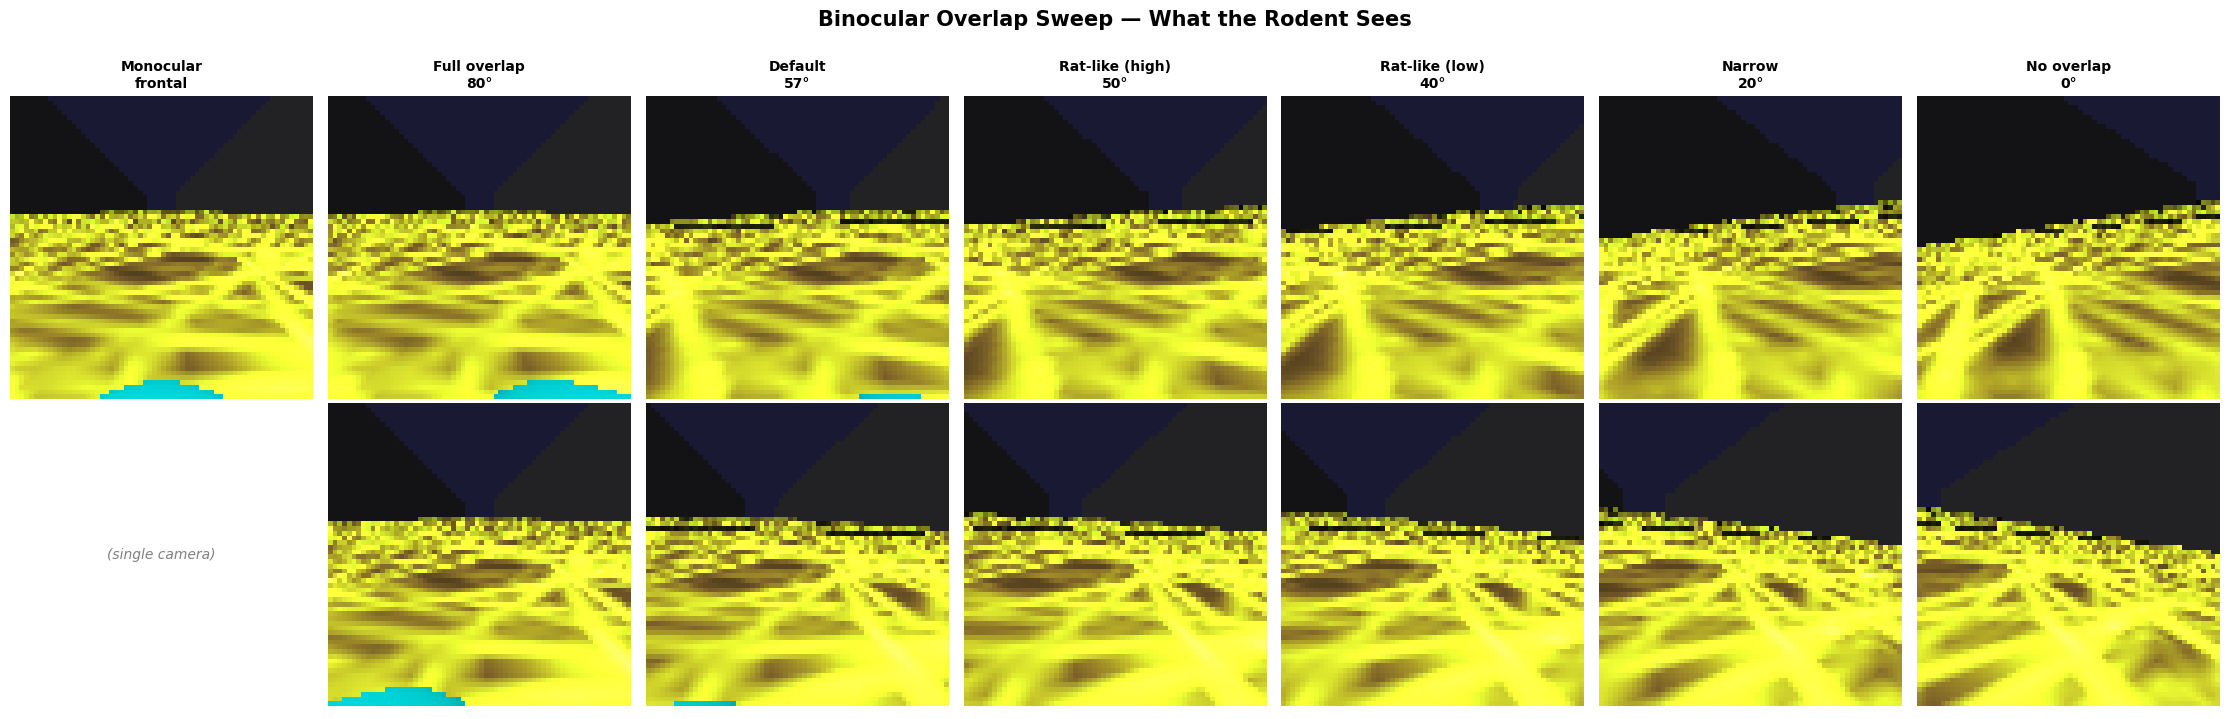

In [10]:
n_cond = len(CONDITIONS)
fig, axes = plt.subplots(2, n_cond, figsize=(3.2 * n_cond, 7))

for col, (label, binocular, offset, overlap_deg) in enumerate(CONDITIONS):
    imgs = rendered_images[label]

    if binocular:
        axes[0, col].imshow(imgs["left"])
        axes[1, col].imshow(imgs["right"])
    else:
        # Monocular: show the same ego image in both rows
        axes[0, col].imshow(imgs["ego"])
        axes[1, col].text(
            0.5,
            0.5,
            "(single camera)",
            transform=axes[1, col].transAxes,
            ha="center",
            va="center",
            fontsize=10,
            color="gray",
            fontstyle="italic",
        )
        axes[1, col].set_facecolor("#f0f0f0")

    axes[0, col].set_title(label, fontsize=10, fontweight="bold")
    axes[0, col].axis("off")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Left Eye", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Right Eye", fontsize=12, fontweight="bold")

plt.suptitle(
    "Binocular Overlap Sweep — What the Rodent Sees",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

In [11]:
## Empirical Pixel Overlap Measurement
# Compute pixel-wise correlation between left/right images
# to measure how much visual content actually overlaps.

print(f"{'Condition':<22} {'Pixel Corr':>12} {'Nominal Overlap':>16}")
print("-" * 54)

for label, binocular, offset, expected_overlap in CONDITIONS:
    clean_label = label.replace("\n", " ")
    if not binocular or offset is None:
        print(f"{clean_label:<22} {'N/A':>12} {'monocular':>16}")
        continue

    left = rendered_images[label]["left"]
    right = rendered_images[label]["right"]

    left_f = np.array(left, dtype=np.float32)
    right_f = np.array(right, dtype=np.float32)

    # Pixel correlation (flatten and correlate)
    corr = np.corrcoef(left_f.ravel(), right_f.ravel())[0, 1]

    print(f"{clean_label:<22} {corr:>12.3f} {expected_overlap:>14} deg")

Condition                Pixel Corr  Nominal Overlap
------------------------------------------------------
Monocular frontal               N/A        monocular
Full overlap 80°              0.877             80 deg
Default 57°                   0.828             57 deg
Rat-like (high) 50°           0.831             50 deg
Rat-like (low) 40°            0.813             40 deg
Narrow 20°                    0.806             20 deg
No overlap 0°                 0.794              0 deg


## 5. Visual Field Geometry Diagrams

Top-down schematic showing how the left and right eye fields overlap for each
binocular condition. The shaded region in the center is the binocular overlap zone.

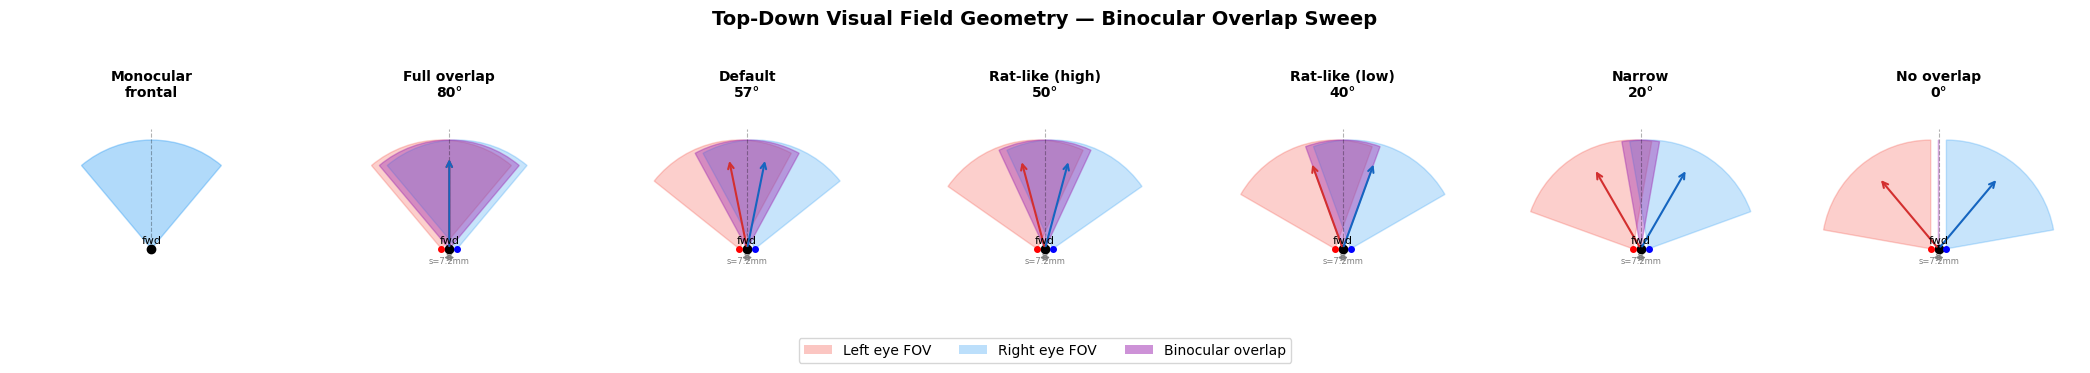

In [12]:
def draw_visual_field(
    ax, offset_deg, fovy=80, title="", overlap_deg=None, eye_separation=0.008 * 0.9
):
    """Draw a top-down visual field diagram with eye separation."""
    half_fov = fovy / 2
    eye_y = min(eye_separation / 2 / 0.05, 0.15)

    if offset_deg is None:
        wedge = Wedge(
            (0, 0),
            1.0,
            theta1=90 - half_fov,
            theta2=90 + half_fov,
            alpha=0.35,
            color="#2196F3",
            label="Egocentric",
        )
        ax.add_patch(wedge)
    else:
        left_center = 90 + offset_deg
        left_wedge = Wedge(
            (-eye_y, 0),
            1.0,
            theta1=left_center - half_fov,
            theta2=left_center + half_fov,
            alpha=0.25,
            color="#F44336",
            label="Left eye",
        )
        ax.add_patch(left_wedge)

        right_center = 90 - offset_deg
        right_wedge = Wedge(
            (eye_y, 0),
            1.0,
            theta1=right_center - half_fov,
            theta2=right_center + half_fov,
            alpha=0.25,
            color="#2196F3",
            label="Right eye",
        )
        ax.add_patch(right_wedge)

        actual_overlap = fovy - 2 * offset_deg
        if actual_overlap > 0:
            overlap_start = 90 - actual_overlap / 2
            overlap_end = 90 + actual_overlap / 2
            overlap_wedge = Wedge(
                (0, 0),
                1.0,
                theta1=overlap_start,
                theta2=overlap_end,
                alpha=0.4,
                color="#9C27B0",
                label=f"Overlap {actual_overlap:.0f} deg (far-field)",
            )
            ax.add_patch(overlap_wedge)

        ax.plot(-eye_y, 0, "ro", markersize=4, zorder=5)
        ax.plot(eye_y, 0, "bo", markersize=4, zorder=5)

        ax.annotate(
            "",
            xy=(eye_y, -0.08),
            xytext=(-eye_y, -0.08),
            arrowprops=dict(arrowstyle="<->", color="gray", lw=1),
        )
        ax.text(
            0,
            -0.13,
            f"s={eye_separation*1000:.1f}mm",
            ha="center",
            fontsize=6,
            color="gray",
        )

        for angle, color in [(left_center, "#D32F2F"), (right_center, "#1565C0")]:
            rad = np.radians(angle)
            dx, dy = 0.85 * np.cos(rad), 0.85 * np.sin(rad)
            ax.annotate(
                "",
                xy=(dx, dy),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.5),
            )

    ax.plot([0, 0], [0, 1.1], "k--", alpha=0.3, lw=0.8)
    ax.plot(0, 0, "ko", markersize=6)
    ax.annotate("fwd", (0, 0.08), ha="center", va="center", fontsize=8, color="k")
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-0.3, 1.3)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)
    ax.axis("off")


# Draw all conditions
fig, axes = plt.subplots(1, n_cond, figsize=(3 * n_cond, 3.5))

for col, (label, binocular, offset, overlap_deg) in enumerate(CONDITIONS):
    if binocular:
        offset_deg = np.degrees(offset)
        draw_visual_field(axes[col], offset_deg, title=label, overlap_deg=overlap_deg)
    else:
        draw_visual_field(axes[col], None, title=label)

# Add a shared legend
legend_elements = [
    mpatches.Patch(facecolor="#F44336", alpha=0.3, label="Left eye FOV"),
    mpatches.Patch(facecolor="#2196F3", alpha=0.3, label="Right eye FOV"),
    mpatches.Patch(facecolor="#9C27B0", alpha=0.5, label="Binocular overlap"),
]
fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=3,
    fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05),
)

plt.suptitle(
    "Top-Down Visual Field Geometry — Binocular Overlap Sweep",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## 6. Combined: Vision + Field Diagram per Condition

Each column shows the visual field schematic on top, with left/right eye renders below.

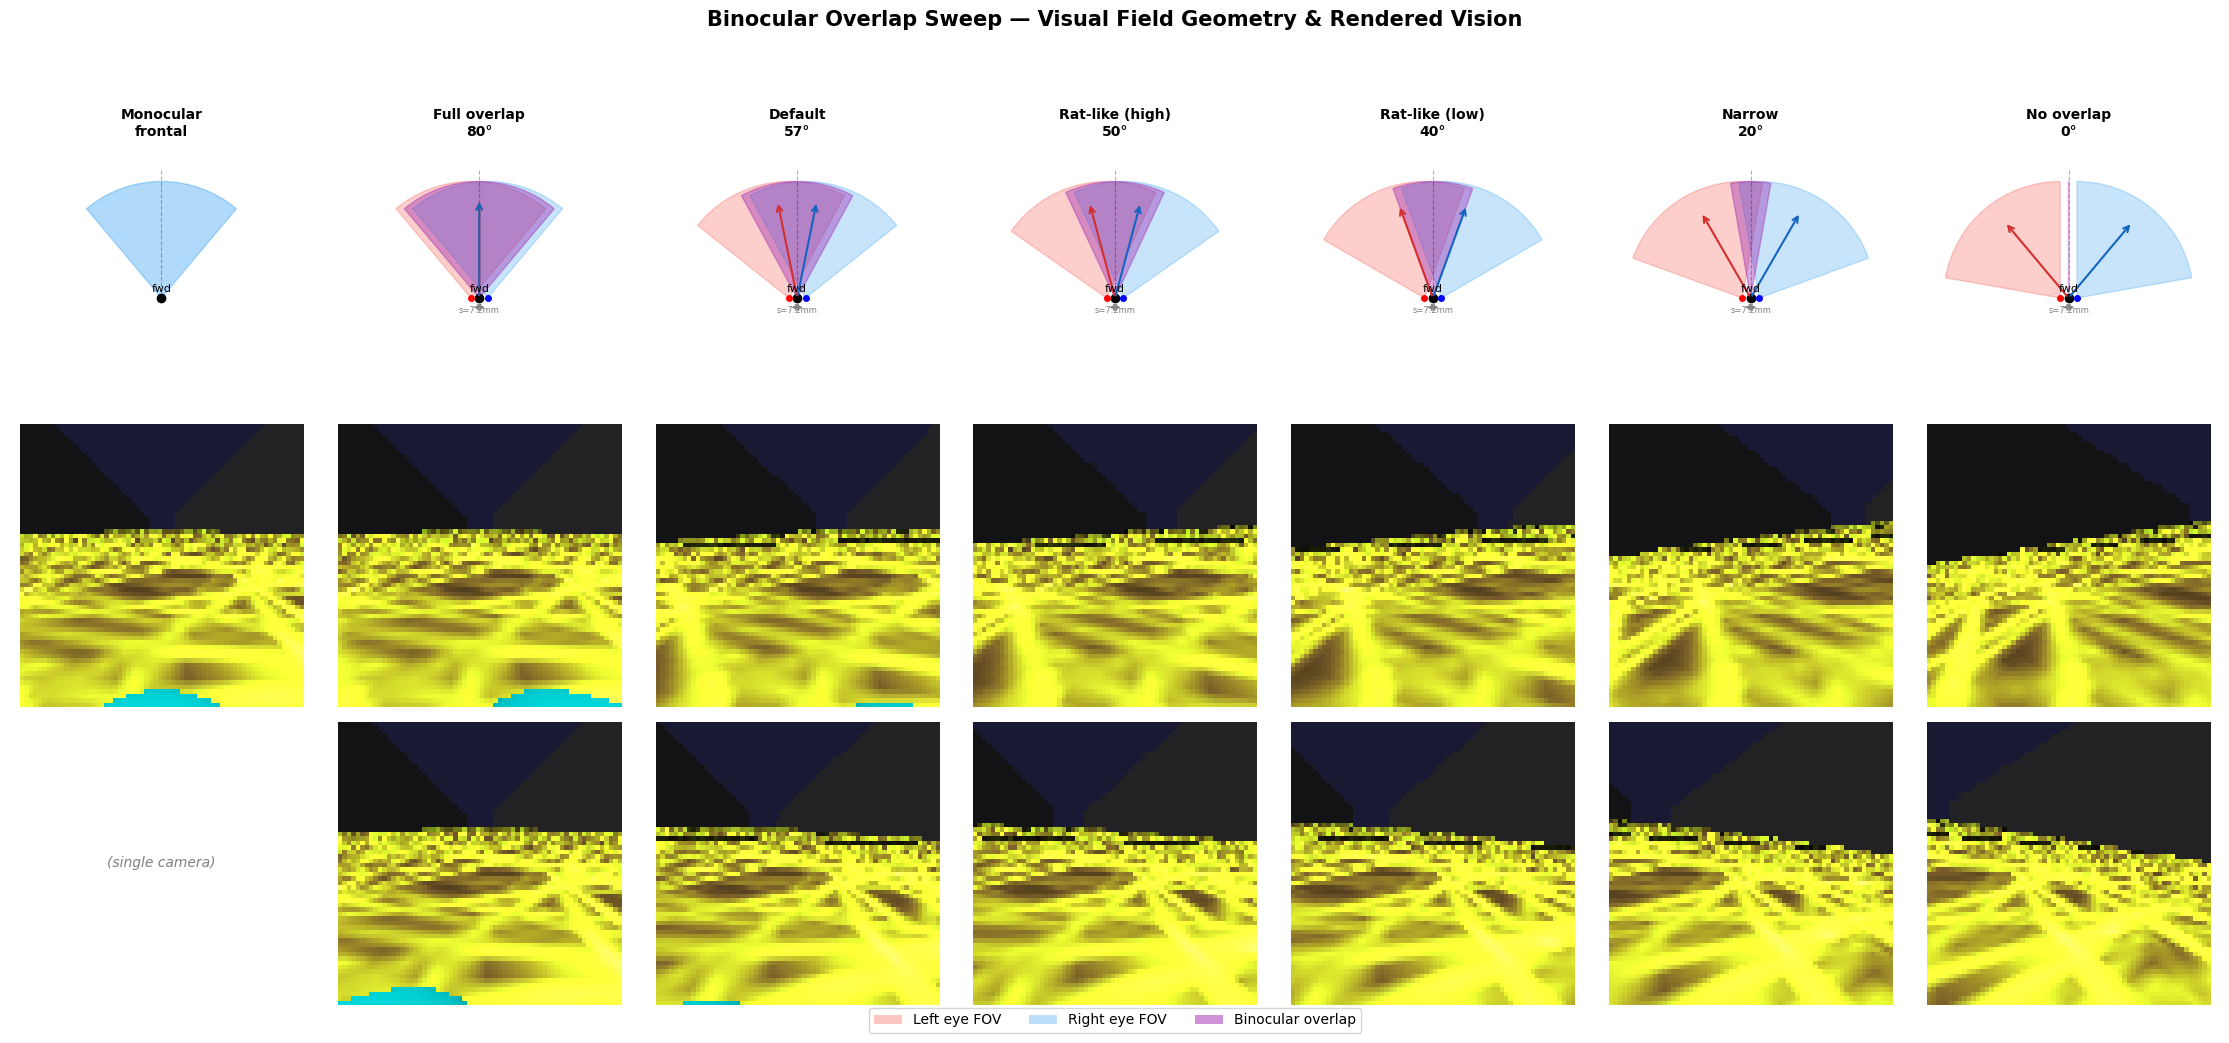

In [13]:
fig, axes = plt.subplots(
    3,
    n_cond,
    figsize=(3.2 * n_cond, 10),
    gridspec_kw={"height_ratios": [1.2, 1, 1]},
)

for col, (label, binocular, offset, overlap_deg) in enumerate(CONDITIONS):
    # Row 0: Visual field diagram
    if binocular:
        offset_deg = np.degrees(offset)
        draw_visual_field(
            axes[0, col], offset_deg, title=label, overlap_deg=overlap_deg
        )
    else:
        draw_visual_field(axes[0, col], None, title=label)

    # Rows 1-2: Rendered vision
    imgs = rendered_images[label]
    if binocular:
        axes[1, col].imshow(imgs["left"])
        axes[2, col].imshow(imgs["right"])
    else:
        axes[1, col].imshow(imgs["ego"])
        axes[2, col].text(
            0.5,
            0.5,
            "(single camera)",
            transform=axes[2, col].transAxes,
            ha="center",
            va="center",
            fontsize=10,
            color="gray",
            fontstyle="italic",
        )
        axes[2, col].set_facecolor("#f0f0f0")

    axes[1, col].axis("off")
    axes[2, col].axis("off")

axes[1, 0].set_ylabel("Left Eye", fontsize=11, fontweight="bold")
axes[2, 0].set_ylabel("Right Eye", fontsize=11, fontweight="bold")

# Shared legend
legend_elements = [
    mpatches.Patch(facecolor="#F44336", alpha=0.3, label="Left eye FOV"),
    mpatches.Patch(facecolor="#2196F3", alpha=0.3, label="Right eye FOV"),
    mpatches.Patch(facecolor="#9C27B0", alpha=0.5, label="Binocular overlap"),
]
fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=3,
    fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02),
)

plt.suptitle(
    "Binocular Overlap Sweep — Visual Field Geometry & Rendered Vision",
    fontsize=15,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

## 7. Vision Across Multiple Timesteps

Render a few timesteps for each condition to show how the views evolve as the
rodent moves (zero-action rollout — the rodent falls/slides naturally).

In [14]:
SAMPLE_STEPS = [0, 10, 20, 30, 40, 50]  # which rollout steps to render
N_TOTAL_STEPS = max(SAMPLE_STEPS) + 1

# Pick a few representative conditions
SELECTED = [0, 1, 3, 5, 6]  # monocular, full, rat-like high, narrow, no overlap

multi_images = {}  # (label, step) -> {"left": img, "right": img} or {"ego": img}

for idx in tqdm(SELECTED, desc="Multi-step rendering"):
    label, binocular, offset, overlap_deg = CONDITIONS[idx]
    env = envs[label]
    rng = jax.random.PRNGKey(42)
    state = jax.jit(env.reset)(rng)
    step_fn = jax.jit(env.step)

    for step in range(N_TOTAL_STEPS):
        state = step_fn(state, jp.zeros(env.action_size))
        if step in SAMPLE_STEPS:
            batched_data = add_batch_dim(state.data)
            if binocular:
                left = np.array(
                    jax.jit(renderers[label]["left"].render)(batched_data)[0]
                )
                right = np.array(
                    jax.jit(renderers[label]["right"].render)(batched_data)[0]
                )
                multi_images[(label, step)] = {"left": left, "right": right}
            else:
                ego = np.array(jax.jit(renderers[label]["ego"].render)(batched_data)[0])
                multi_images[(label, step)] = {"ego": ego}

print(f"Rendered {len(multi_images)} frames across {len(SELECTED)} conditions.")

Multi-step rendering: 100%|██████████| 5/5 [00:18<00:00,  3.71s/it]

Rendered 30 frames across 5 conditions.


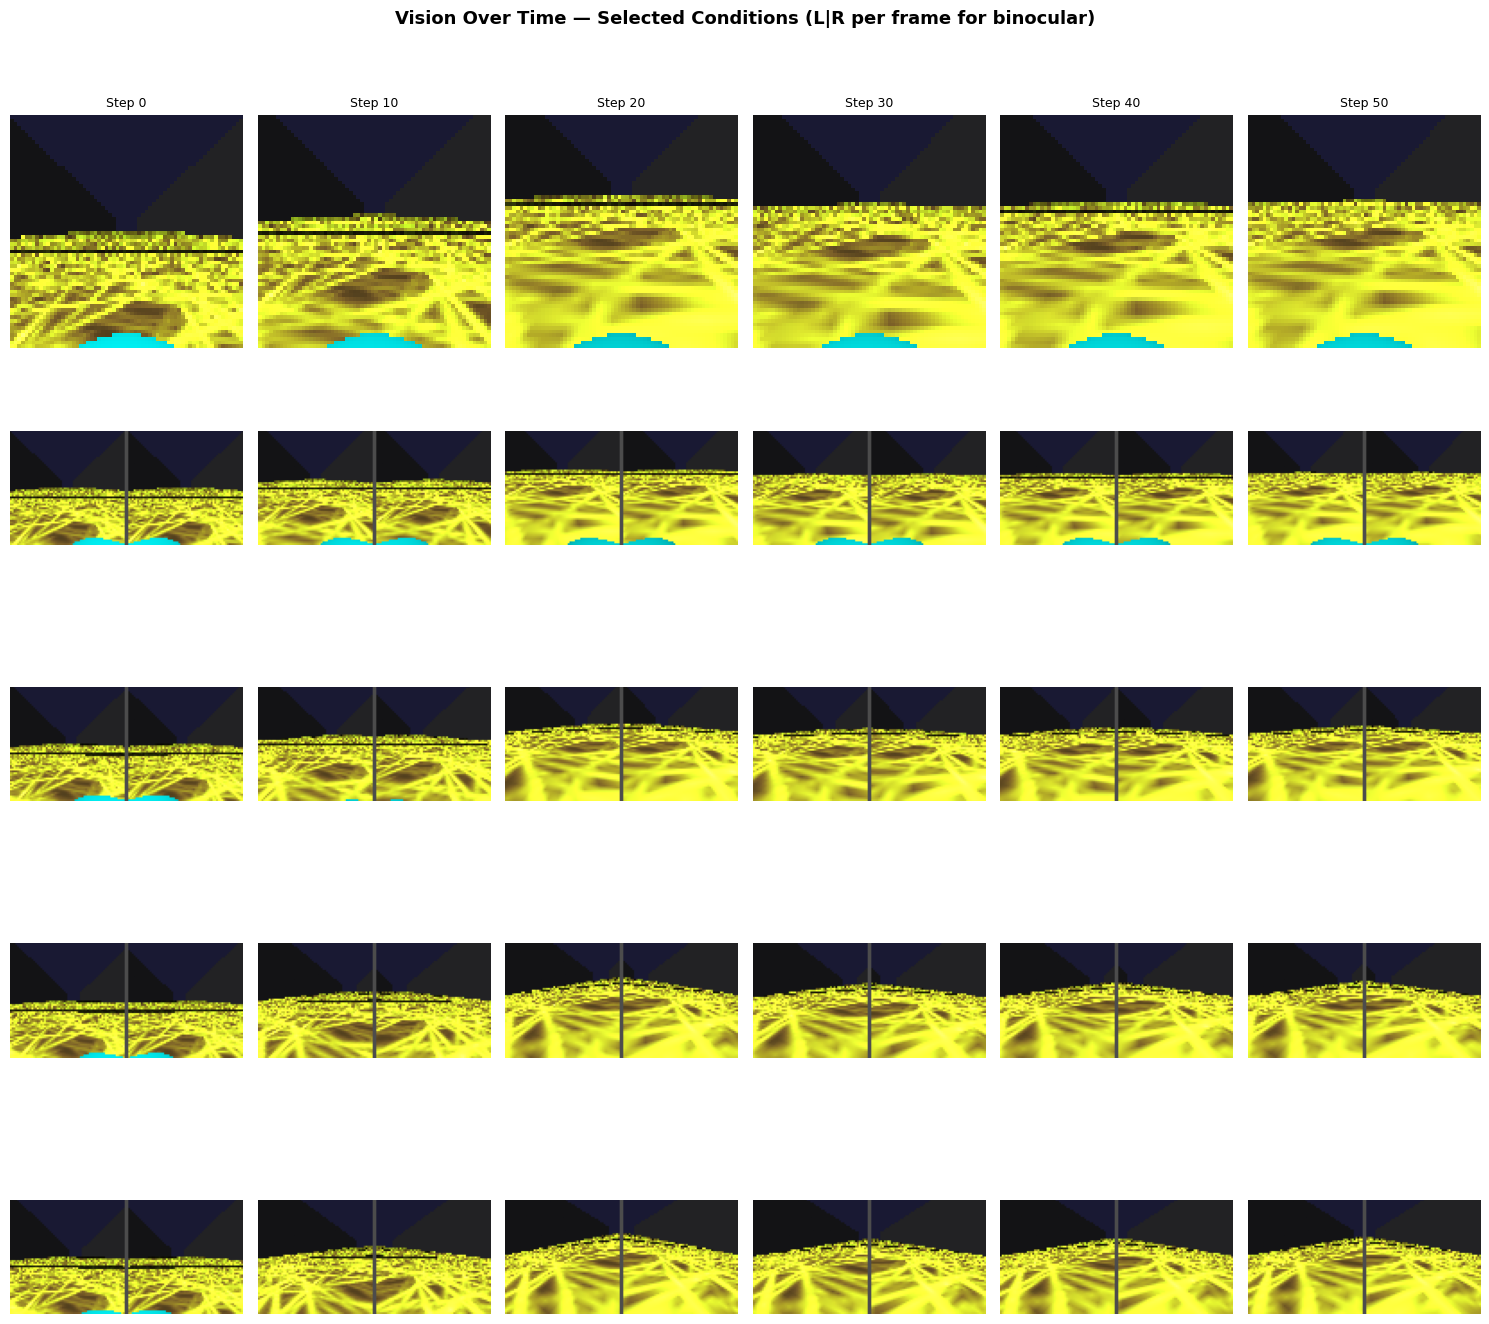

In [15]:
n_sel = len(SELECTED)
n_steps = len(SAMPLE_STEPS)

fig, axes = plt.subplots(n_sel, n_steps, figsize=(2.5 * n_steps, 2.8 * n_sel))

for row_i, idx in enumerate(SELECTED):
    label, binocular, offset, overlap_deg = CONDITIONS[idx]
    for col_i, step in enumerate(SAMPLE_STEPS):
        imgs = multi_images[(label, step)]
        if binocular:
            # Show left and right side by side with a thin separator
            left = imgs["left"]
            right = imgs["right"]
            sep = np.ones((HEIGHT, 2, 3), dtype=left.dtype) * 0.3
            combined = np.concatenate([left, sep, right], axis=1)
            axes[row_i, col_i].imshow(combined)
        else:
            axes[row_i, col_i].imshow(imgs["ego"])

        axes[row_i, col_i].axis("off")
        if row_i == 0:
            axes[row_i, col_i].set_title(f"Step {step}", fontsize=9)

    axes[row_i, 0].set_ylabel(label, fontsize=9, fontweight="bold")

plt.suptitle(
    "Vision Over Time — Selected Conditions (L|R per frame for binocular)",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

## Notes

**Overlap formula:** `overlap_deg ≈ fovy - 2 × degrees(eye_angle_offset)` (valid for square aspect ratio, 32×32 training images).

**Literature context:**
- Real rat binocular overlap varies widely (40–90°) depending on eye position (Wallace et al. 2013, Nature)
- Rat eyes move independently — up to 40° horizontal divergence
- Our model uses fixed, yoked cameras (primate-like), which is more generous than real rat vision
- The "rat-like" conditions (40–50°) match horizontal-plane estimates from Heesy 2004

**What to look for in training results:**
- As overlap narrows, do agents develop head-bobbing (motion parallax)?
- At what overlap does gap-crossing performance degrade?
- Does monocular frontal outperform binocular (as expected for fixed cameras)?